In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Create folders
os.makedirs('E:/Projects/HR-Attrition-Analysis/images/', exist_ok=True)

print("All libraries imported successfully ")
print(f"Scikit-learn ready for ML ")

All libraries imported successfully 
Scikit-learn ready for ML 


In [2]:
path = 'E:/Projects/HR-Attrition-Analysis/data/'
df = pd.read_csv(path + 'WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nAttrition value counts:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.1f}%")

Dataset shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


In [3]:
print("=== DATASET OVERVIEW ===\n")
print(f"Total Employees: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nNumerical columns: {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical columns: {df.select_dtypes(include='object').shape[1]}")

=== DATASET OVERVIEW ===

Total Employees: 1470
Total Features: 35

Missing Values: 0

Data Types:
int64     26
object     9
Name: count, dtype: int64

Numerical columns: 26
Categorical columns: 9


In [4]:
cols_to_drop = ['EmployeeCount', 'EmployeeNumber',
                'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped 4 useless columns ")
print(f"New shape: {df.shape}")

Dropped 4 useless columns 
New shape: (1470, 31)


In [5]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

# Color palette for attrition
colors = {'Yes': '#FF6B6B', 'No': '#4ECDC4'}
print("Styling ready ")

Styling ready 


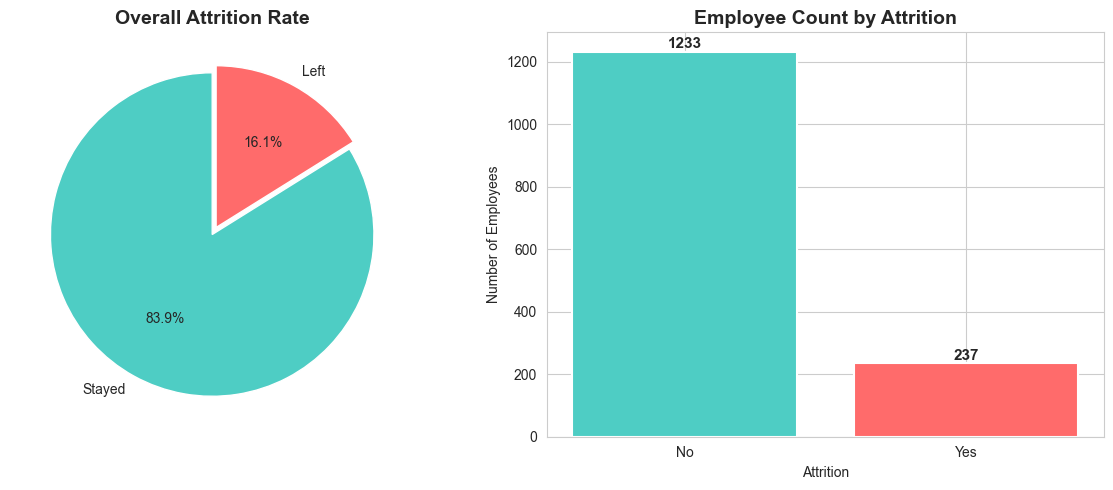

Chart 1 saved


In [6]:
attrition_counts = df['Attrition'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(attrition_counts.values,
            labels=['Stayed', 'Left'],
            autopct='%1.1f%%',
            colors=['#4ECDC4', '#FF6B6B'],
            startangle=90,
            explode=[0, 0.05])
axes[0].set_title('Overall Attrition Rate',
                   fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(attrition_counts.index,
                   attrition_counts.values,
                   color=['#4ECDC4', '#FF6B6B'],
                   edgecolor='white', linewidth=1.5)
axes[1].set_title('Employee Count by Attrition',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Attrition')
axes[1].set_ylabel('Number of Employees')
for bar, val in zip(bars, attrition_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 f'{val}', ha='center',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/1_attrition_overview.png', dpi=150)
plt.show()
print("Chart 1 saved")

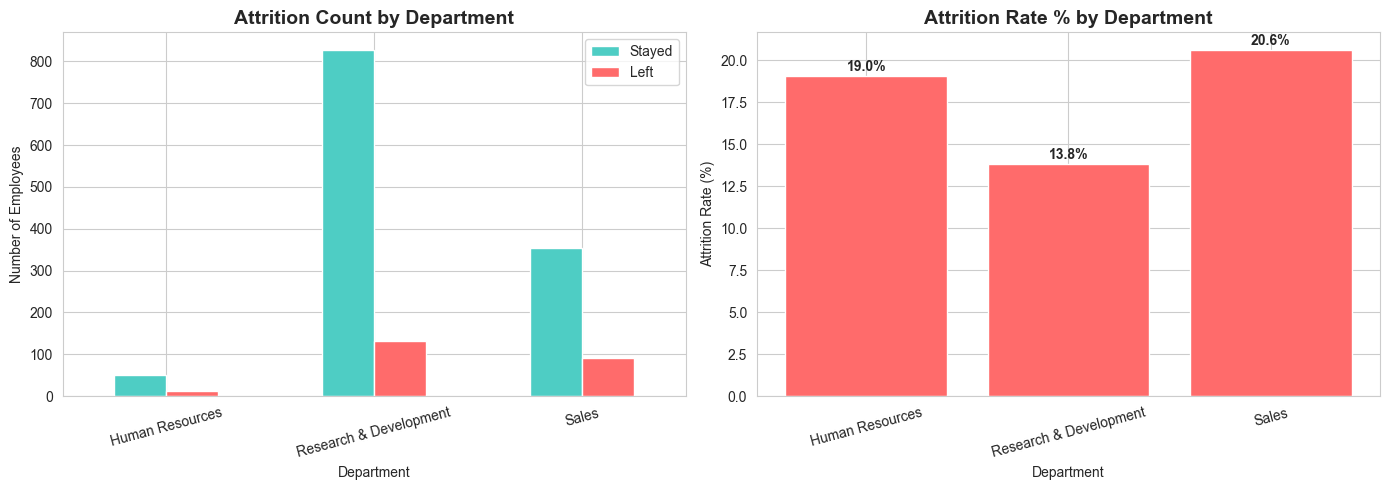

 Chart 2 saved


In [7]:
dept_attrition = df.groupby(['Department', 'Attrition']).size().unstack()
dept_attrition['Attrition_Rate'] = (
    dept_attrition['Yes'] /
    (dept_attrition['Yes'] + dept_attrition['No']) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
dept_attrition[['No', 'Yes']].plot(
    kind='bar', ax=axes[0],
    color=['#4ECDC4', '#FF6B6B'],
    edgecolor='white')
axes[0].set_title('Attrition Count by Department',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Number of Employees')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['Stayed', 'Left'])

# Attrition rate
bars = axes[1].bar(dept_attrition.index,
                   dept_attrition['Attrition_Rate'],
                   color='#FF6B6B', edgecolor='white')
axes[1].set_title('Attrition Rate % by Department',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, dept_attrition['Attrition_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/2_attrition_by_department.png', dpi=150)
plt.show()
print(" Chart 2 saved")

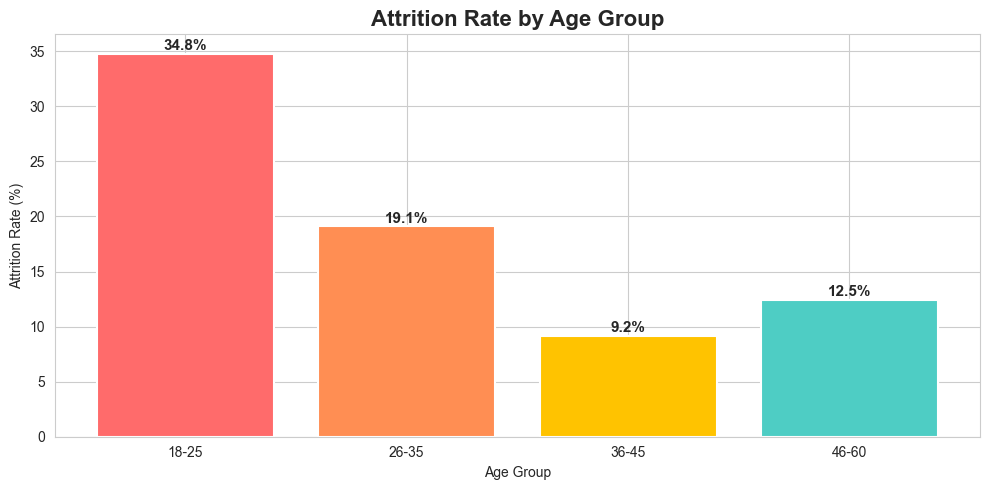

 Chart 3 saved


In [9]:
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[18, 25, 35, 45, 60],
                          labels=['18-25', '26-35', '36-45', '46-60'])

age_attrition = df.groupby(['Age_Group', 'Attrition']).size().unstack()
age_attrition['Attrition_Rate'] = (
    age_attrition['Yes'] /
    (age_attrition['Yes'] + age_attrition['No']) * 100
)

plt.figure(figsize=(10, 5))
bars = plt.bar(age_attrition.index.astype(str),
               age_attrition['Attrition_Rate'],
               color=['#FF6B6B', '#FF8E53', '#FFC300', '#4ECDC4'],
               edgecolor='white', linewidth=1.5)
plt.title('Attrition Rate by Age Group',
          fontsize=16, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
for bar, val in zip(bars, age_attrition['Attrition_Rate']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/3_attrition_by_age.png', dpi=150)
plt.show()
print(" Chart 3 saved")

<Figure size 1000x500 with 0 Axes>

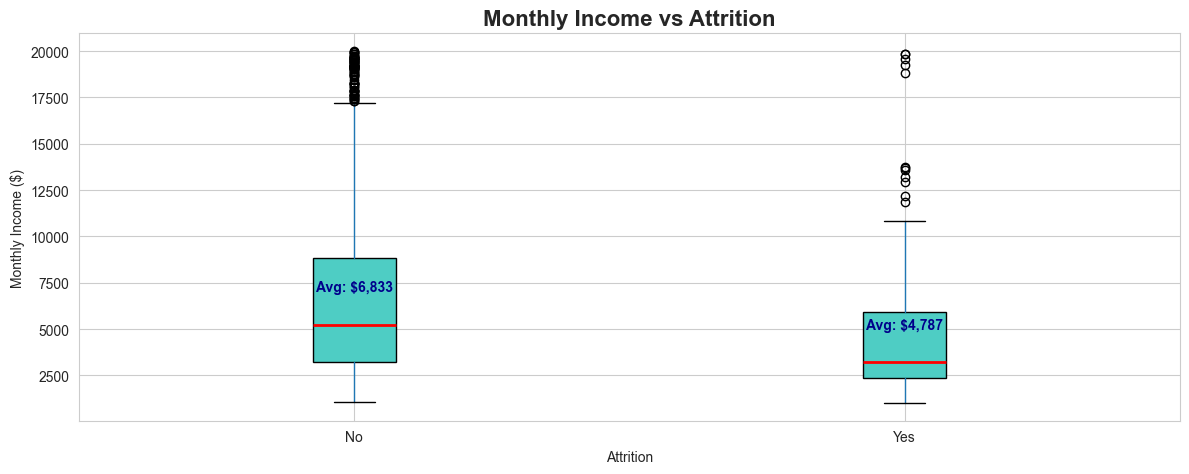

 Chart 4 saved


In [10]:
plt.figure(figsize=(10, 5))
df.boxplot(column='MonthlyIncome',
           by='Attrition',
           patch_artist=True,
           boxprops=dict(facecolor='#4ECDC4'),
           medianprops=dict(color='red', linewidth=2))
plt.title('Monthly Income vs Attrition',
          fontsize=16, fontweight='bold')
plt.suptitle('')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')

# Add mean values
for i, attrition in enumerate(['No', 'Yes'], 1):
    mean_val = df[df['Attrition'] == attrition]['MonthlyIncome'].mean()
    plt.text(i, mean_val + 200,
             f'Avg: ${mean_val:,.0f}',
             ha='center', fontsize=10,
             fontweight='bold', color='darkblue')

plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/4_income_vs_attrition.png', dpi=150)
plt.show()
print(" Chart 4 saved")

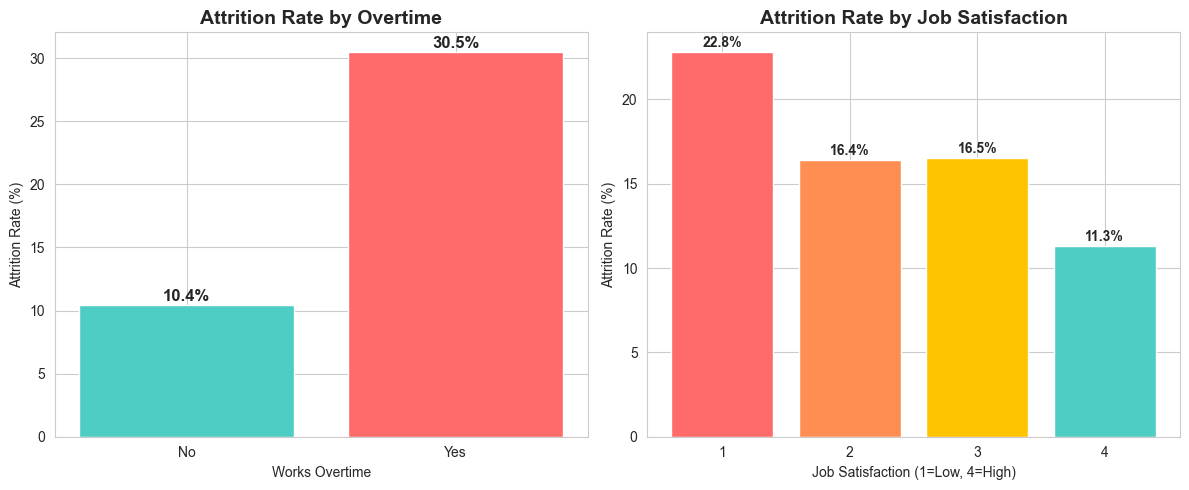

Chart 5 saved


In [11]:
overtime_attrition = df.groupby(['OverTime', 'Attrition']).size().unstack()
overtime_attrition['Attrition_Rate'] = (
    overtime_attrition['Yes'] /
    (overtime_attrition['Yes'] + overtime_attrition['No']) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overtime attrition rate
bars = axes[0].bar(overtime_attrition.index,
                   overtime_attrition['Attrition_Rate'],
                   color=['#4ECDC4', '#FF6B6B'],
                   edgecolor='white')
axes[0].set_title('Attrition Rate by Overtime',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Works Overtime')
axes[0].set_ylabel('Attrition Rate (%)')
for bar, val in zip(bars, overtime_attrition['Attrition_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center',
                 fontsize=12, fontweight='bold')

# Job satisfaction vs attrition
satisfaction_attrition = df.groupby(
    ['JobSatisfaction', 'Attrition']
).size().unstack()
satisfaction_attrition['Attrition_Rate'] = (
    satisfaction_attrition['Yes'] /
    (satisfaction_attrition['Yes'] +
     satisfaction_attrition['No']) * 100
)
bars2 = axes[1].bar(
    satisfaction_attrition.index.astype(str),
    satisfaction_attrition['Attrition_Rate'],
    color=['#FF6B6B', '#FF8E53', '#FFC300', '#4ECDC4'],
    edgecolor='white')
axes[1].set_title('Attrition Rate by Job Satisfaction',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Job Satisfaction (1=Low, 4=High)')
axes[1].set_ylabel('Attrition Rate (%)')
for bar, val in zip(bars2,
                    satisfaction_attrition['Attrition_Rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/5_overtime_satisfaction.png', dpi=150)
plt.show()
print("Chart 5 saved")

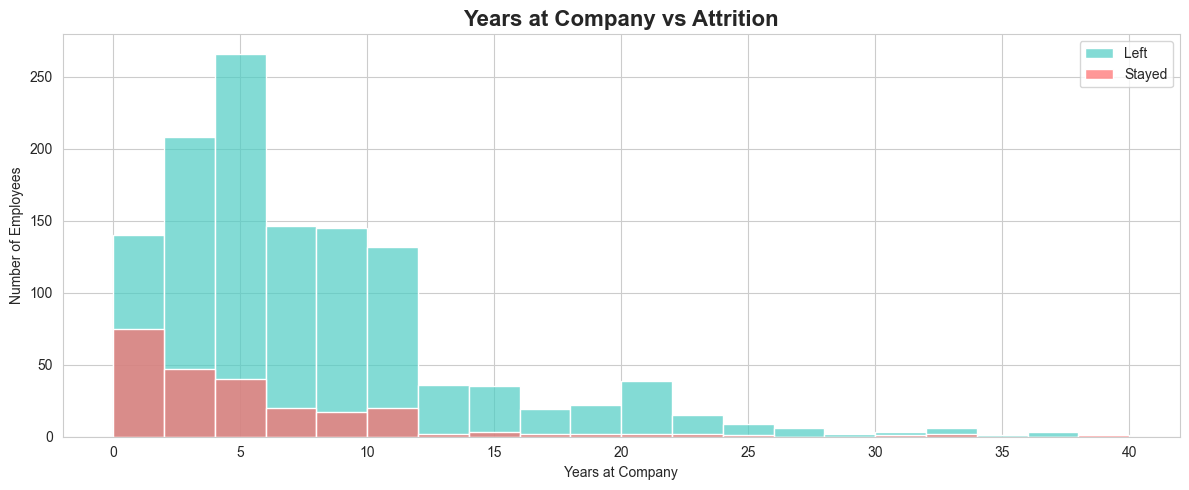

 Chart 6 saved


In [14]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='YearsAtCompany',
             hue='Attrition',
             palette={'Yes': '#FF6B6B', 'No': '#4ECDC4'},
             bins=20, alpha=0.7)
plt.title('Years at Company vs Attrition',
          fontsize=16, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Number of Employees')
plt.legend(['Left', 'Stayed'])
plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/6_years_vs_attrition.png', dpi=150)
plt.show()
print(" Chart 6 saved")

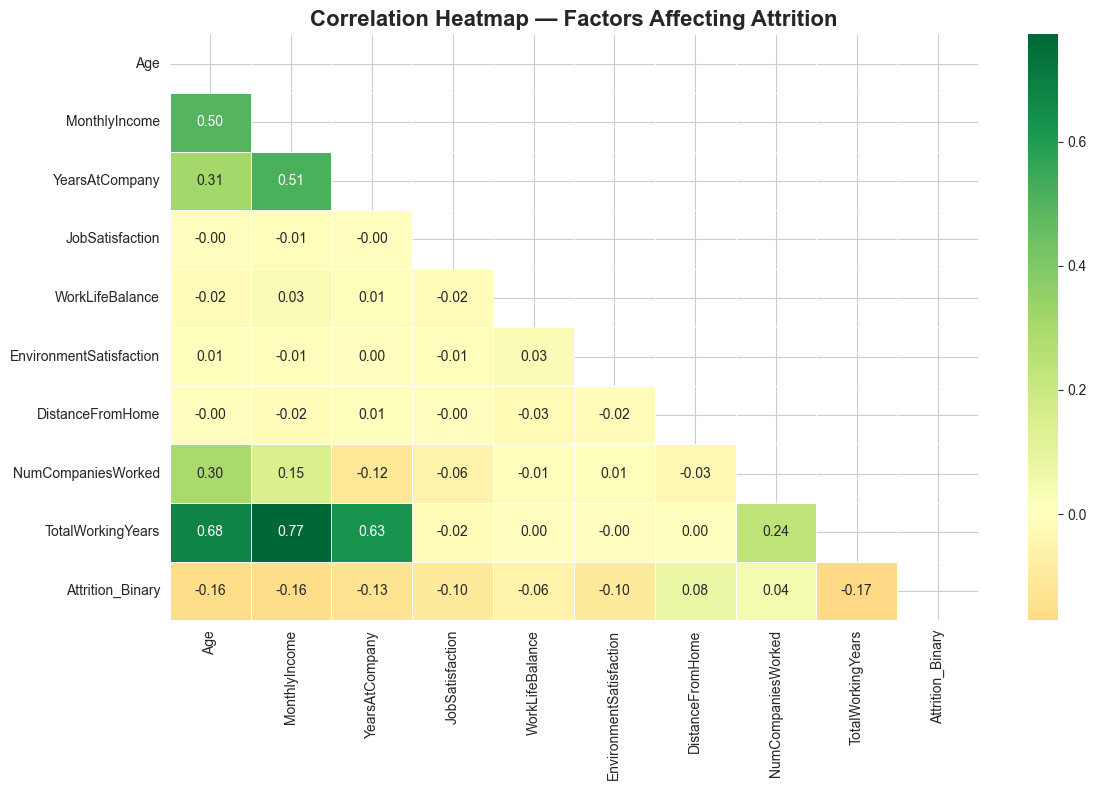

Chart 7 saved


In [15]:
# Create binary attrition column for correlation
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

# Select numerical columns
num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany',
            'JobSatisfaction', 'WorkLifeBalance',
            'EnvironmentSatisfaction', 'DistanceFromHome',
            'NumCompaniesWorked', 'TotalWorkingYears',
            'Attrition_Binary']

plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5)
plt.title('Correlation Heatmap — Factors Affecting Attrition',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/7_correlation_heatmap.png', dpi=150)
plt.show()
print("Chart 7 saved")

In [16]:
print("=" * 55)
print("       KEY EDA INSIGHTS")
print("=" * 55)

# Insight 1
sales_attrition = df[df['Department'] == 'Sales']['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f"\n Insight 1 — Highest Risk Department")
print(f"   Sales department has {sales_attrition:.1f}% attrition rate")
print(f"   → Needs immediate retention intervention")

# Insight 2
young_attrition = df[df['Age_Group'] == '18-25']['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f"\n Insight 2 — Age Risk")
print(f"   18-25 age group has {young_attrition:.1f}% attrition rate")
print(f"   → Young employees need better growth opportunities")

# Insight 3
ot_yes = df[df['OverTime'] == 'Yes']['Attrition'].value_counts(normalize=True)['Yes'] * 100
ot_no = df[df['OverTime'] == 'No']['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f"\n Insight 3 — Overtime Impact")
print(f"   Overtime employees: {ot_yes:.1f}% attrition")
print(f"   Non-overtime employees: {ot_no:.1f}% attrition")
print(f"   → Overtime increases attrition by {ot_yes - ot_no:.1f}%")

# Insight 4
avg_income_left = df[df['Attrition'] == 'Yes']['MonthlyIncome'].mean()
avg_income_stayed = df[df['Attrition'] == 'No']['MonthlyIncome'].mean()
print(f"\n Insight 4 — Salary Impact")
print(f"   Avg salary of employees who LEFT: ${avg_income_left:,.0f}")
print(f"   Avg salary of employees who STAYED: ${avg_income_stayed:,.0f}")
print(f"   → Employees who left earned ${avg_income_stayed - avg_income_left:,.0f} less")

# Insight 5
early_attrition = df[df['YearsAtCompany'] <= 2]['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f"\n Insight 5 — Tenure Risk")
print(f"   Employees with ≤2 years tenure: {early_attrition:.1f}% attrition")
print(f"   → First 2 years are critical for retention")

print("\n" + "=" * 55)
print("EDA Complete  — Ready for Machine Learning!")

       KEY EDA INSIGHTS

 Insight 1 — Highest Risk Department
   Sales department has 20.6% attrition rate
   → Needs immediate retention intervention

 Insight 2 — Age Risk
   18-25 age group has 34.8% attrition rate
   → Young employees need better growth opportunities

 Insight 3 — Overtime Impact
   Overtime employees: 30.5% attrition
   Non-overtime employees: 10.4% attrition
   → Overtime increases attrition by 20.1%

 Insight 4 — Salary Impact
   Avg salary of employees who LEFT: $4,787
   Avg salary of employees who STAYED: $6,833
   → Employees who left earned $2,046 less

 Insight 5 — Tenure Risk
   Employees with ≤2 years tenure: 29.8% attrition
   → First 2 years are critical for retention

EDA Complete  — Ready for Machine Learning!


In [17]:
print("=== PREPARING DATA FOR ML ===\n")

# Separate features and target
X = df.drop(columns=['Attrition', 'Attrition_Binary', 'Age_Group'])
y = df['Attrition_Binary']

# Check categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

# Label encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print(f"\nAfter encoding:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nAttrition distribution:")
print(f"Stayed (0): {(y==0).sum()} employees")
print(f"Left (1):   {(y==1).sum()} employees")
print("\nData ready for ML ")

=== PREPARING DATA FOR ML ===

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

After encoding:
Features shape: (1470, 30)
Target shape: (1470,)

Attrition distribution:
Stayed (0): 1233 employees
Left (1):   237 employees

Data ready for ML 


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # maintains same attrition ratio in both sets
)

print("=== TRAIN TEST SPLIT ===\n")
print(f"Training set:  {X_train.shape[0]} employees")
print(f"Testing set:   {X_test.shape[0]} employees")
print(f"\nTraining attrition rate: {y_train.mean()*100:.1f}%")
print(f"Testing attrition rate:  {y_test.mean()*100:.1f}%")
print("\nSplit complete ")

=== TRAIN TEST SPLIT ===

Training set:  1176 employees
Testing set:   294 employees

Training attrition rate: 16.2%
Testing attrition rate:  16.0%

Split complete 


In [19]:
print("=== LOGISTIC REGRESSION ===\n")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_roc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])

print(f"Accuracy:  {lr_accuracy*100:.2f}%")
print(f"ROC-AUC Score: {lr_roc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred,
                            target_names=['Stayed', 'Left']))

=== LOGISTIC REGRESSION ===

Accuracy:  86.73%
ROC-AUC Score: 0.777

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.98      0.93       247
        Left       0.75      0.26      0.38        47

    accuracy                           0.87       294
   macro avg       0.81      0.62      0.65       294
weighted avg       0.85      0.87      0.84       294



In [20]:
print("=== RANDOM FOREST ===\n")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5
)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"Accuracy:  {rf_accuracy*100:.2f}%")
print(f"ROC-AUC Score: {rf_roc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred,
                            target_names=['Stayed', 'Left']))

=== RANDOM FOREST ===

Accuracy:  83.33%
ROC-AUC Score: 0.801

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294



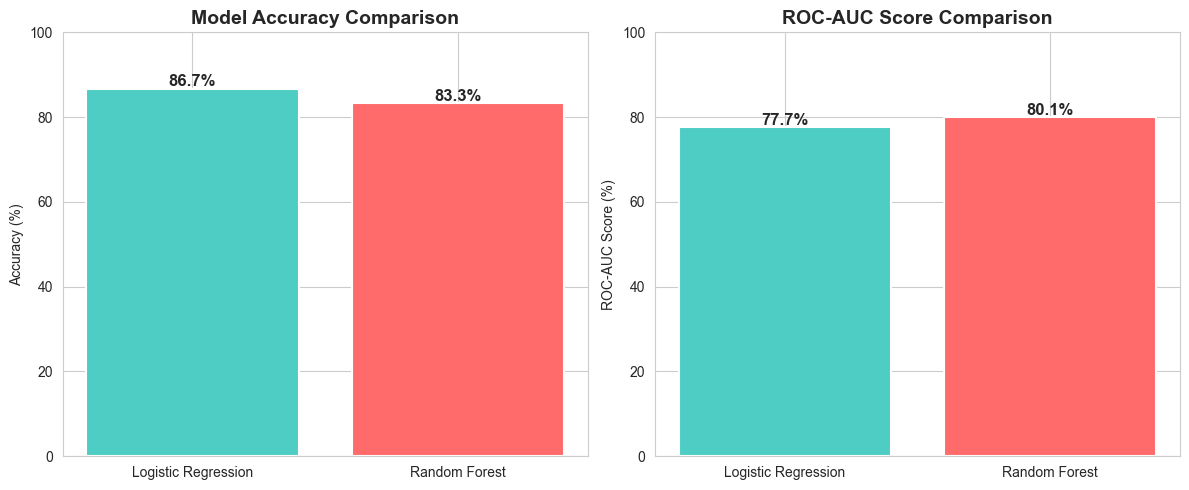

Chart 8 saved


In [21]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_accuracy * 100, rf_accuracy * 100]
roc_scores = [lr_roc * 100, rf_roc * 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
bars1 = axes[0].bar(models, accuracies,
                    color=['#4ECDC4', '#FF6B6B'],
                    edgecolor='white', linewidth=1.5)
axes[0].set_title('Model Accuracy Comparison',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([0, 100])
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center',
                 fontsize=12, fontweight='bold')

# ROC-AUC comparison
bars2 = axes[1].bar(models, roc_scores,
                    color=['#4ECDC4', '#FF6B6B'],
                    edgecolor='white', linewidth=1.5)
axes[1].set_title('ROC-AUC Score Comparison',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score (%)')
axes[1].set_ylim([0, 100])
for bar, val in zip(bars2, roc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/8_model_comparison.png', dpi=150)
plt.show()
print("Chart 8 saved")

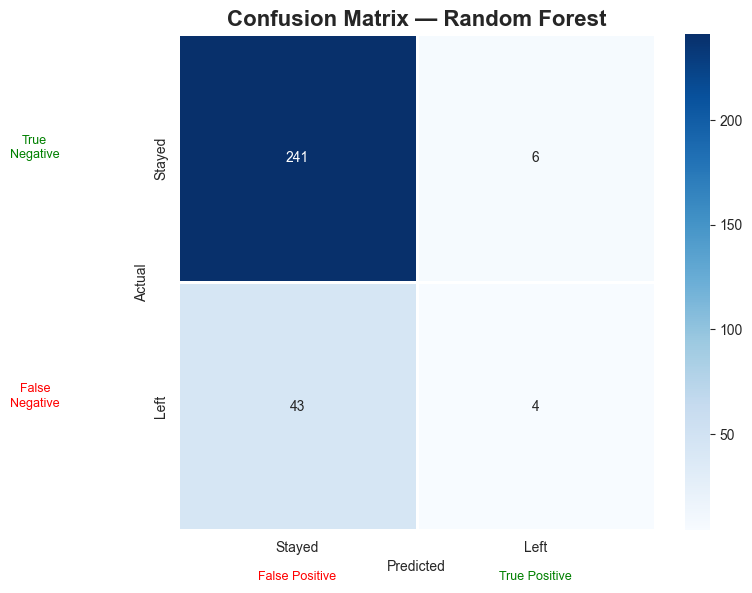


=== CONFUSION MATRIX EXPLAINED ===
True Negative  (correctly predicted Stayed): 241
True Positive  (correctly predicted Left):   4
False Positive (predicted Left, actually Stayed): 6
False Negative (predicted Stayed, actually Left): 43

Out of 47 employees who actually left,
our model correctly identified 4 of them 


In [22]:
# Use Random Forest as it usually performs better
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'],
            linewidths=2)
plt.title('Confusion Matrix — Random Forest',
          fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Add labels explaining each quadrant
plt.text(-0.6, 0.5, 'True\nNegative', color='green',
         fontsize=9, ha='center')
plt.text(-0.6, 1.5, 'False\nNegative', color='red',
         fontsize=9, ha='center')
plt.text(0.5, 2.2, 'False Positive', color='red',
         fontsize=9, ha='center')
plt.text(1.5, 2.2, 'True Positive', color='green',
         fontsize=9, ha='center')

plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/9_confusion_matrix.png', dpi=150)
plt.show()

# Print what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f"\n=== CONFUSION MATRIX EXPLAINED ===")
print(f"True Negative  (correctly predicted Stayed): {tn}")
print(f"True Positive  (correctly predicted Left):   {tp}")
print(f"False Positive (predicted Left, actually Stayed): {fp}")
print(f"False Negative (predicted Stayed, actually Left): {fn}")
print(f"\nOut of {tp+fn} employees who actually left,")
print(f"our model correctly identified {tp} of them ")

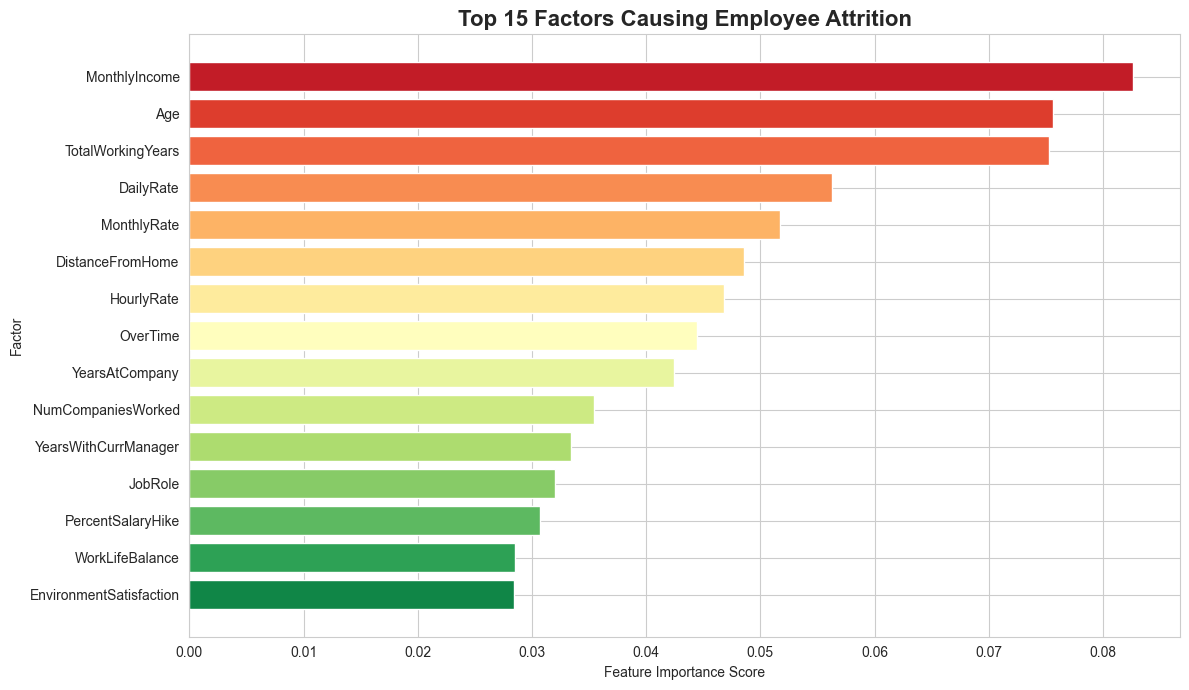

Chart 10 saved

Top 5 factors causing attrition:
  MonthlyIncome: 0.083
  Age: 0.076
  TotalWorkingYears: 0.075
  DailyRate: 0.056
  MonthlyRate: 0.052


In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 7))
bars = plt.barh(feature_importance['Feature'][::-1],
                feature_importance['Importance'][::-1],
                color=sns.color_palette("RdYlGn_r", 15))
plt.title('Top 15 Factors Causing Employee Attrition',
          fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Factor')
plt.tight_layout()
plt.savefig('E:/Projects/HR-Attrition-Analysis/images/10_feature_importance.png', dpi=150)
plt.show()
print("Chart 10 saved")
print(f"\nTop 5 factors causing attrition:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.3f}")

In [24]:
print("=== REAL WORLD PREDICTION DEMO ===\n")

# Save cleaned data for Power BI
df.to_csv('E:/Projects/HR-Attrition-Analysis/data/hr_clean.csv',
          index=False)

# Model summary
print(" FINAL MODEL SUMMARY")
print("=" * 45)
print(f"Algorithm: Random Forest Classifier")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Total features:   {X_train.shape[1]}")
print(f"Accuracy:         {rf_accuracy*100:.2f}%")
print(f"ROC-AUC Score:    {rf_roc:.3f}")
print("=" * 45)
print(f"\n Model saved and data exported for Power BI!")
print(f" hr_clean.csv saved in data/ folder")

=== REAL WORLD PREDICTION DEMO ===

 FINAL MODEL SUMMARY
Algorithm: Random Forest Classifier
Training samples: 1176
Testing samples:  294
Total features:   30
Accuracy:         83.33%
ROC-AUC Score:    0.801

 Model saved and data exported for Power BI!
 hr_clean.csv saved in data/ folder


In [25]:
print(f" Model Accuracy: {rf_accuracy*100:.1f}%")
print(f" ROC-AUC Score: {rf_roc:.3f}")
print(f"\n Charts saved: Check your images/ folder")
print(f"   Should have 10 PNG files")

# Verify all images saved
import os
images = os.listdir('E:/Projects/HR-Attrition-Analysis/images/')
print(f"\nImages found: {len(images)}")
for img in sorted(images):
    print(f"   {img}")

 Model Accuracy: 83.3%
 ROC-AUC Score: 0.801

 Charts saved: Check your images/ folder
   Should have 10 PNG files

Images found: 10
   10_feature_importance.png
   1_attrition_overview.png
   2_attrition_by_department.png
   3_attrition_by_age.png
   4_income_vs_attrition.png
   5_overtime_satisfaction.png
   6_years_vs_attrition.png
   7_correlation_heatmap.png
   8_model_comparison.png
   9_confusion_matrix.png
